In [14]:
%pip install --upgrade pylhe>=0.9.2

Note: you may need to restart the kernel to use updated packages.


In [1]:
import LHE_mixer_for_git.LHE_mixer as LHE_mixer
import os
import awkward as ak
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pylhe
print("LHE_mixer source file", LHE_mixer.__file__)

LHE_mixer source file /eos/home-i04/c/chiw/JpsiJpsiUps/MC_samples/workspace/playground/LHE_mixer_for_git/LHE_mixer.py


In [2]:
test_gg_path = '/eos/user/c/chiw/JpsiJpsiUps/MC_samples/LHE/SPS-gg/sample_gg_28765_Evts.lhe'
test_gg_file = pylhe.read_lhe_with_attributes(test_gg_path)
test_gg_ak   = pylhe.to_awkward(test_gg_file)

WARNING. Parse Error: no element found: line 201363, column 8


In [3]:
ak.type(test_gg_ak)

ArrayType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['nparticles', 'pid', 'weight', 'scale', 'aqed', 'aqcd'], parameters={'__record__': 'EventInfo'}), ListType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['px', 'py', 'pz', 'e'], parameters={'__record__': 'Momentum4D'}), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['vector', 'id', 'status', 'mother1', 'mother2', 'color1', 'color2', 'm', 'lifetime', 'spin'], parameters={'__record__': 'Particle'}))], ['eventinfo', 'particles'], parameters={'__record__': 'Event'}), 28765, None)

In [4]:
test_single_J_path = "/eos/user/c/chiw/JpsiJpsiUps/MC_samples/LHE/SPS-Jpsi/filter_JpsiPtMin4p0/nonBatch_SPS_J_HO_PtMin4p0_YAbsMin3p0_17_8258Evts.lhe"
test_single_J_file = pylhe.read_lhe_with_attributes(test_single_J_path)
test_single_J_ak   = pylhe.to_awkward(test_single_J_file)

In [5]:
ak.type(test_single_J_ak)

ArrayType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['nparticles', 'pid', 'weight', 'scale', 'aqed', 'aqcd'], parameters={'__record__': 'EventInfo'}), ListType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['px', 'py', 'pz', 'e'], parameters={'__record__': 'Momentum4D'}), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['vector', 'id', 'status', 'mother1', 'mother2', 'color1', 'color2', 'm', 'lifetime', 'spin'], parameters={'__record__': 'Particle'}))], ['eventinfo', 'particles'], parameters={'__record__': 'Event'}), 8258, None)

In [6]:
test_SPS_JpsiJpsi_path = "/eos/user/c/chiw/JpsiJpsiUps/MC_samples/LHE/SPS-JpsiJpsi/SPS_JpsiJpsi_HO_PtMin4_YabsMax3_100.lhe"
test_SPS_JpsiJpsi_file = pylhe.read_lhe_with_attributes(test_SPS_JpsiJpsi_path)
test_SPS_JpsiJpsi_ak   = pylhe.to_awkward(test_SPS_JpsiJpsi_file)

In [7]:
ak.type(test_SPS_JpsiJpsi_ak)

ArrayType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['nparticles', 'pid', 'weight', 'scale', 'aqed', 'aqcd'], parameters={'__record__': 'EventInfo'}), ListType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['px', 'py', 'pz', 'e'], parameters={'__record__': 'Momentum4D'}), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['vector', 'id', 'status', 'mother1', 'mother2', 'color1', 'color2', 'm', 'lifetime', 'spin'], parameters={'__record__': 'Particle'}))], ['eventinfo', 'particles'], parameters={'__record__': 'Event'}), 57959, None)

In [8]:
px = test_gg_ak.particles.vector.x
py = test_gg_ak.particles.vector.y
pt2 = px**2 + py**2
gluon_id = 21
mask_gluon_final_highpt = (test_gg_ak.particles.id == gluon_id) & (test_gg_ak.particles.status == 1) & (pt2 > 3 ** 2)
mask_event = ak.any(mask_gluon_final_highpt, axis=1)

In [9]:
test_gg_PtMin3_ak = test_gg_ak[mask_event]

In [10]:
ak.type(test_gg_PtMin3_ak)

ArrayType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['nparticles', 'pid', 'weight', 'scale', 'aqed', 'aqcd'], parameters={'__record__': 'EventInfo'}), ListType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['px', 'py', 'pz', 'e'], parameters={'__record__': 'Momentum4D'}), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['vector', 'id', 'status', 'mother1', 'mother2', 'color1', 'color2', 'm', 'lifetime', 'spin'], parameters={'__record__': 'Particle'}))], ['eventinfo', 'particles'], parameters={'__record__': 'Event'}), 24886, None)

Begin mixing.

In [11]:
test_mix_DPS_JpsiJpsi_gg = LHE_mixer.lhe_event_ak_mixer(
    [test_gg_PtMin3_ak, test_SPS_JpsiJpsi_ak],
    [1, 1],
    [24886, 57959],
    sort_particles_by_status=True
)

In [12]:
test_mix_DPS_JpsiJpsi_gg_path = '/eos/user/c/chiw/JpsiJpsiUps/MC_samples/LHE/DPS-JpsiJpsi-gg/test_mix_DPS_JpsiJpsi_gg.lhe'
pylhe.write_lhe_file_path(
    LHE_mixer.lhe_ak_to_lhe_file(test_mix_DPS_JpsiJpsi_gg, pylhe.read_lhe_init(test_gg_path)),
    test_mix_DPS_JpsiJpsi_gg_path
)

Examine the $p_T$ distribution of $gg \to gg$ samples:

Text(0, 0.5, 'Events / 0.12 GeV')

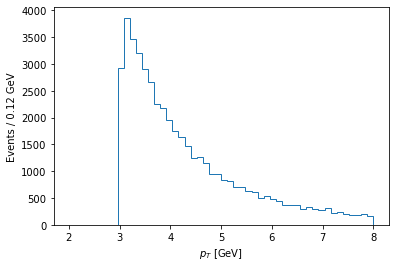

In [13]:
test_gg_ak_gluon_out = test_gg_PtMin3_ak.particles[(test_gg_PtMin3_ak.particles.id == 21) & (test_gg_PtMin3_ak.particles.status == 1)]
test_gg_ak_gluon_out_pt = ak.flatten(ak.fill_none(test_gg_ak_gluon_out.vector.pt, 0))
plt.hist(test_gg_ak_gluon_out_pt, bins=50, range=(2, 8), histtype='step', label='$gg \\to gg$ samples')
plt.xlabel('$p_T$ [GeV]')
plt.ylabel('Events / 0.12 GeV')